# Using autofe: propose features, validate them, loop

| Section | Covers |
| --- | --- |
| [1. Inputs](#1) | the materials a run needs, how to prepare them, and checking them |
| [2. Feature discovery](#2) | an LLM proposes candidates; each is screened on a small sample |
| [3. XGBoost validation](#3) | the five stages that decide which candidates earn a place |
| [4. The loop](#4) | keep what passed, propose again from the stronger incumbent set |

In [45]:
# Re-import src/ modules whenever they change, so an edit to the package is picked
# up without restarting the kernel. Without it, a kernel that imported the old code
# keeps running it.
%load_ext autoreload
%autoreload 2

import json
import os
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")   # tqdm, via shap

# The repo root, wherever this notebook is run from.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)   # config paths are relative to the repo root, as from the CLI

from validation import Pipeline, build_dataset, load_config

pd.set_option("display.width", 200, "display.max_columns", 40, "display.max_colwidth", 80)
CONFIG = "configs/cdss_us_sbs.yaml"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<a id='1'></a>
## 1. Inputs

A run reads **materials prepared once** by the dataset's prepare notebook - `data/<dataset>/prepare.ipynb` here - plus **one config** that says how to use them. Nothing is split or sampled at run time: the three tables are read exactly as written.

| Material | Config key | Read by |
| --- | --- | --- |
| `train.csv` · `valid.csv` · `test.csv` | `data.paths` | every stage |
| `column_descriptions.json` | `discovery.column_descriptions_path` | discovery: what each column means |
| `few_shot.csv` | `discovery.few_shot_path` | discovery: the example rows the proposer sees |
| `screen_train.csv` · `screen_valid.csv` | `discovery.screen_paths` | discovery: the rows its screen fits and scores on |

What the config declares about them:

| Key | Here |
| --- | --- |
| `data.target` | `bankrupt` |
| `data.id_cols` | `row_id` - for the leakage check and the few-shot ids |
| `features.base` | empty, so every other numeric column is an incumbent |
| `features.new` | the cash-flow family and the two planted controls |
| `discovery.task_description` | what the data is, in domain terms - the proposer's only briefing |

### Checking the input materials

The same materials for the bankruptcy demo were written by `data/bankruptcy/prepare.ipynb`. Every path below comes from `configs/bankruptcy.yaml`:

In [46]:
cfg = load_config(CONFIG)
materials = {
    **{f"data.paths.{name}": path for name, path in cfg.data.paths.items()},
    "discovery.column_descriptions_path": cfg.discovery.column_descriptions_path,
    "discovery.few_shot_path": cfg.discovery.few_shot_path,
    **{f"discovery.screen_paths.{name}": path for name, path in cfg.discovery.screen_paths.items()},
}
for key, path in materials.items():
    status = "ok" if Path(path).exists() else "MISSING"
    print(f"{key:<36} {path:<46} {status}")

data.paths.train                     data/cdss_us_sbs/train.csv                     ok
data.paths.valid                     data/cdss_us_sbs/valid.csv                     ok
data.paths.test                      data/cdss_us_sbs/test.csv                      ok
discovery.column_descriptions_path   data/cdss_us_sbs/column_descriptions.json      ok
discovery.few_shot_path              data/cdss_us_sbs/few_shot.csv                  ok
discovery.screen_paths.train         data/cdss_us_sbs/screen_train.csv              ok
discovery.screen_paths.valid         data/cdss_us_sbs/screen_valid.csv              ok


In [47]:
dataset = build_dataset(cfg)
print(dataset.describe())
print("declared candidates:", dataset.new_features)

2026-09-28 16:59:49,865 | INFO    | validation.data              | reading data/cdss_us_sbs/train.csv as csv


2026-09-28 17:00:28,687 | INFO    | validation.data              | reading data/cdss_us_sbs/valid.csv as csv
2026-09-28 17:00:42,363 | INFO    | validation.data              | reading data/cdss_us_sbs/test.csv as csv
2026-09-28 17:00:55,340 | INFO    | validation.data              | features.base not given; inferred 302 incumbent column(s)
2026-09-28 17:01:16,784 | INFO    | validation.data              | dataset ready: {'rows_per_split': {'train': 1928522, 'valid': 808158, 'test': 755426}, 'n_base_features': 302, 'n_new_features': 0, 'target': 'default'}
{'rows_per_split': {'train': 1928522, 'valid': 808158, 'test': 755426}, 'n_base_features': 302, 'n_new_features': 0, 'target': 'default'}
declared candidates: []


In [48]:
descriptions = json.loads(Path(cfg.discovery.column_descriptions_path).read_text())
few_shot = pd.read_csv(cfg.discovery.few_shot_path)

print(f"{len(descriptions)} column descriptions, e.g.")
for column in dataset.base_features[:3]:
    print(f"  {column:<56} {descriptions.get(column, '(none)')}")
first = few_shot.query("batch == 0")
print(f"\nfew-shot rows: {few_shot['batch'].nunique()} batches of {len(first)}; "
      f"batch 0 holds {int(first[cfg.data.target].sum())} bankrupt companies")

302 column descriptions, e.g.
  ac99dmcg                                                 AC99DMCG: Normalised accum $ weighted by MAXSECTG for unpaid Period. Variable category: Amex Spending Pattern.
  ac99dvcg                                                 AC99DVCG: Normalised accum $ weighted by AVGSECTG for unpaid Period. Variable category: Amex Spending Pattern.
  air_d30                                                  AIR_D30: Airline spend in last 30 days; Accum $ of approved charges wehre AIR_IND = 1 in the last 30-180 days for the transaction customer. Variable category: Amex Spending Pattern.

few-shot rows: 10 batches of 32; batch 0 holds 16 bankrupt companies


<a id='2'></a>
## 2. Feature discovery

An LLM reads the task description and every incumbent column - its description and its values in the few-shot rows - and proposes a batch of new columns as pandas code. Each proposal runs in a sandbox and is **screened**: an XGBoost model with and without it, fitted on a sample of train and scored on a sample of valid. The screen is cheap and noisy by design; it gives the proposer feedback each round, while the decision is section 3's, on the full splits.

The knobs, under `discovery:` in the config:

| Key | Here | What it does |
| --- | --- | --- |
| `strategy` | `caafe` | how the LLM is asked: `caafe`, `elfgym`, `ferg`, `featllm` or `promptfe` |
| `batch_size` | 5 | proposals per round |
| `max_rounds` | 2 | rounds; each one sees every earlier proposal and its screen score |
| `screen_data` | `files` | what the screen fits and scores on: `splits` (the whole train and valid splits) or `files` (rows the prepare notebook sampled from them) |
| `screen_paths` | `screen_train.csv`, `screen_valid.csv` | those samples, in the same format as the splits - class-balanced here, since 3% positives would leave almost none |
| `history_path` | `outputs/discovery_history/bankruptcy.csv` | every earlier proposal with its verdict and the reason, read into the prompt; round numbers and the few-shot rotation continue from it |
| `llm.model` | `gpt-4o` | which model proposes |

Scoring on valid means the proposer's feedback comes from valid rows, so valid stops being an independent check on the features it proposes; test still is.

In [57]:
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(usecwd=True))

True

In [58]:
from discovery.stage import run_discovery_stage

cfg_discovery = load_config(CONFIG, {"discovery.enabled": True})
discovered = run_discovery_stage(cfg_discovery, dataset,
                                 output_dir=ROOT / "outputs" / "usage_discovery")
print(json.dumps(discovered.summary(), indent=5))

2026-09-28 17:19:50,300 | INFO    | validation.data              | reading data/cdss_us_sbs/screen_train.csv as csv
2026-09-28 17:19:50,870 | INFO    | validation.data              | reading data/cdss_us_sbs/screen_valid.csv as csv


/Users/mliu30/_proj_case_copilot/Modeling/autofe/src/validation/data.py:179: DtypeWarning: Columns (304) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, float_precision="round_trip")


2026-09-28 17:19:51,218 | INFO    | discovery.stage              | discovery: redundancy limit |rho|<=0.80 (from feature_selection.spearman)
2026-09-28 17:19:51,219 | INFO    | discovery.stage              | discovery: strategy=caafe backend=safechain model=gpt-5 metric=adjusted Gini
2026-09-28 17:19:51,219 | INFO    | discovery.stage              | discovery: the screen fits on 22664 row(s) (718 positive) and scores on 9183 (278 positive), from data/cdss_us_sbs/screen_train.csv and data/cdss_us_sbs/screen_valid.csv; 302 base features
2026-09-28 17:19:53,553 | INFO    | discovery.stage              | discovery: 7/302 columns barely vary across rows and are flagged in the prompt; a ratio pairing one with a varying column reproduces that column and is rejected as redundant
2026-09-28 17:19:53,554 | INFO    | discovery.stage              | discovery: 12/302 columns presented as coded categories (levels, not ranges)
2026-09-28 17:19:53,555 | INFO    | validation.data              | reading

In [51]:
ledger = discovered.to_frame()
ledger[["round", "feature_name", "rationale", "input_columns", "delta", "error"]].round(4)

,round,feature_name,rationale,input_columns,delta,error
0,1,risk_weighted_one_way_spend_concentration,"Captures convergence of spend concentration with merchant/industry risk, ali...","cl1wirsk, c1wesrsk, hsespcnc, cuespcnc",0.0016,None
1,1,payment_channel_concentration_risk,Measures operational single-point-of-failure risk by scaling payment-channel...,"cupchrsk, cupmchct",0.0001,None
2,1,inquiry_utilization_pressure_index,Interacts recent external inquiry pressure with combined external and Amex u...,"hcuiqitu, cervaubp, casutlrl",0.0026,None
3,1,min_due_payment_intensity_ratio,Identifies revolving pay-rate cliffs by scaling average minimum-due frequenc...,"mcavmdte, itexpd01",NaN,Generated feature 'min_due_payment_intensity_ratio' is redundant: |rho|=0.99...
4,1,acute_trigger_recency_index,"Measures clustering of recent acute events (utilization increases, over-limi...","ons30dpo, dslstdrg, ons30brd, ons30bin, ons30acd, ons30uin, ceovlt30, ceons3...",0.0001,Dropped on the full splits: Generated feature 'acute_trigger_recency_index' ...
5,2,oop_to_paydown_stress_ratio,Captures mismatch between rising out-of-pattern/internal+external debt stres...,"intoop, inttdbt1, cuhlocpd, culocpd1, openpydn, lendpydn",NaN,Generated feature 'oop_to_paydown_stress_ratio' is redundant: |rho|=0.903 ag...
6,2,fico_trend_oop_stress,Detects transitions from chronic to acute stress when FICO momentum turns ne...,"intoop, itexoop1, hdhscrti",0.0031,None
7,2,credit_seeking_instability_rate,Measures intensity of new-credit seeking and inquiry pressure (consumer bure...,"cpr6inct, lnorcage, ceons30i, lniqct2y, hcuiqitu, lnciqidx",-0.0013,None
8,2,p2p_liquidity_drain_index,Flags potential cash extraction/liquidity drain via P2P channels by combinin...,"totp2psp, cuavrjw2, p2prts30, p2putl30",NaN,Generated feature 'p2p_liquidity_drain_index' spikes on the sample data: lar...
9,2,risky_merchant_shift_concentration_index,Captures operational structuring by detecting when recent industry shift coi...,"cuashft6, clavhrsk, hselowtn, hsespcnc, cuespcnc",0.0000,Dropped on the full splits: Generated feature 'risky_merchant_shift_concentr...


In [40]:
ran = ledger[ledger["error"].isna()]
print(ran.iloc[0]["code"] if len(ran) else "no proposal ran cleanly")

widened = discovered.dataset
print(f"\ncandidates now: {len(widened.new_features)} = {len(dataset.new_features)} declared "
      f"+ {len(discovered.kept_features)} discovered")

# (payment_channel_concentration_risk, Payment-channel concentration adjusted by channel risk)
# Usefulness: Captures operational/funding single-point-of-failure risk by amplifying high payment-channel risk when the customer relies on fewer payment channels. This operational concentration often precedes payment disruption.
# Evidence:
# - Observed current-data: df["cupmchct"] ranges 1–4 and df["cupchrsk"] ranges ~0.012–0.091; some default rows show higher df["cupchrsk"] with low df["cupmchct"], indicating reliance on few channels with higher channel risk.
# - Schema-based reasoning: “Payment-channel concentration” is called out as a potential vulnerability; this feature directly encodes that vulnerability.

# Source fields: None (current df only)
# Feature grain: transaction
# Join key: Not applicable
# Event timestamp: Not applicable
# Lookback window: None
# As-of rule: Uses only same-as-of transaction features; no future information
# Query requirements: None
df["payment_channel_con

<a id='3'></a>
## 3. XGBoost validation

Every candidate - declared and discovered alike - goes through the same five stages, on the full splits:

| Stage | Question | Config |
| --- | --- | --- |
| 1. data quality | is the column usable, and shaped the same in valid / test as in train? | `data_quality.*` |
| 2. feature selection | does it carry signal the incumbents do not already carry? | `feature_selection.*` |
| 3. model builds | XGBoost `base`, `base_plus_new`, and `leave_one_in` - the incumbents plus one candidate | `model.*` |
| 4. analysis | Gini gain per variant on valid and test; SHAP rank | `analysis.*` |
| 5. verdict | four gates per candidate, then KEEP or TRY A NEW BATCH for the batch | `verdict.*` |

The widened dataset from section 2 is passed straight in, so discovery does not run again. From the command line, sections 2 and 3 are one run: `autofe -c configs/bankruptcy.yaml --set discovery.enabled=true`.

- stage by stage

In [52]:
import gc
import resource
import subprocess
import time

from validation import PipelineResult
from validation.logging_utils import setup_logging
from validation.stages.analysis import run_analysis
from validation.stages.data_quality import run_data_quality
from validation.stages.feature_selection import build_verdict_table, run_feature_selection
from validation.stages.modeling import run_modeling
from validation.stages.verdict import run_verdict

cfg_validate = load_config(CONFIG, {
    "run.name": "usage_validation",
    "run.log_level": "INFO",
    "discovery.enabled": False,
})
diagnostic_pipeline = Pipeline(cfg_validate)
diagnostic_output = diagnostic_pipeline.output_dir
setup_logging(cfg_validate.run.log_level, diagnostic_output / "run.log")
diagnostic_pipeline._write_yaml("config.resolved.yaml", cfg_validate.to_dict())

memory_checkpoints = []
diagnostic_started = time.perf_counter()


def memory_checkpoint(stage):
    gc.collect()
    current_mib = int(subprocess.check_output(
        ["ps", "-o", "rss=", "-p", str(os.getpid())], text=True
    ).strip()) / 1024
    peak_raw = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    peak_mib = peak_raw / (1024 ** 2 if sys.platform == "darwin" else 1024)
    previous_mib = memory_checkpoints[-1]["rss_mib"] if memory_checkpoints else current_mib
    row = {
        "stage": stage,
        "elapsed_seconds": time.perf_counter() - diagnostic_started,
        "rss_mib": current_mib,
        "rss_delta_mib": current_mib - previous_mib,
        "peak_rss_mib": peak_mib,
    }
    memory_checkpoints.append(row)
    display(pd.DataFrame([row]).round(1))


candidates = list(widened.new_features)
stage_dataset = widened
memory_checkpoint("baseline")
print(f"diagnostic artifacts -> {diagnostic_output}")

,stage,elapsed_seconds,rss_mib,rss_delta_mib,peak_rss_mib
0,baseline,0.3,3805.6,0.0,11602.2


diagnostic artifacts -> outputs/usage_validation/20260928_171645


In [53]:
stage_started = time.perf_counter()
dq = run_data_quality(stage_dataset, cfg_validate)
if not dq.report.empty:
    diagnostic_pipeline._write_csv("data_quality_report.csv", dq.report)

if dq.failed and cfg_validate.data_quality.drop_failed and cfg_validate.gates_enforced:
    failed = set(dq.failed)
    stage_dataset = stage_dataset.with_features(
        [feature for feature in stage_dataset.base_features if feature not in failed],
        [feature for feature in stage_dataset.new_features if feature not in failed],
    )


print(f"data quality: {time.perf_counter() - stage_started:.1f}s")
memory_checkpoint("data quality")

2026-09-28 17:17:09,572 | INFO    | validation.stages.data_quality | distribution check vs train ...
2026-09-28 17:17:38,631 | INFO    | validation.stages.data_quality | distribution check vs train done in 29.1s
2026-09-28 17:17:38,641 | INFO    | validation.stages.data_quality | distribution: 8/319 feature(s) shift beyond psi 0.25 vs train
2026-09-28 17:17:38,645 | INFO    | validation.stages.data_quality | data quality: 18/319 feature(s) failed {'missing_rate > 0.99': 9, 'psi_max > 0.25': 8, 'n_unique < 2': 7}
data quality: 49.9s


,stage,elapsed_seconds,rss_mib,rss_delta_mib,peak_rss_mib
0,data quality,53.3,560.8,-3244.8,11602.2


In [54]:
stage_started = time.perf_counter()
fs = run_feature_selection(stage_dataset, cfg_validate)
diagnostic_pipeline._write_feature_selection(fs)

carried = fs.selected if cfg_validate.gates_enforced else list(stage_dataset.new_features)
stage_dataset = stage_dataset.with_features(stage_dataset.base_features, carried)
selection_verdicts = build_verdict_table(candidates, fs, dq_failed=dq.failed)
diagnostic_pipeline._write_csv("feature_selection_verdicts.csv", selection_verdicts)

print(f"feature selection: {time.perf_counter() - stage_started:.1f}s; "
      f"{len(stage_dataset.new_features)} candidate(s) carried forward")
memory_checkpoint("feature selection")

2026-09-28 17:17:48,169 | INFO    | validation.stages.feature_selection | feature selection on 200000 row(s) x 319 feature(s)
2026-09-28 17:17:48,422 | INFO    | validation.stages.feature_selection | spearman screen ...
2026-09-28 17:17:52,781 | INFO    | validation.stages.feature_selection | spearman screen done in 4.4s
2026-09-28 17:17:52,781 | INFO    | validation.stages.feature_selection | mutual information screen ...


/Users/mliu30/_proj_case_copilot/Modeling/autofe/src/validation/stages/feature_selection.py:79: RuntimeWarning: divide by zero encountered in matmul
  n = mx.T @ my
/Users/mliu30/_proj_case_copilot/Modeling/autofe/src/validation/stages/feature_selection.py:79: RuntimeWarning: overflow encountered in matmul
  n = mx.T @ my
/Users/mliu30/_proj_case_copilot/Modeling/autofe/src/validation/stages/feature_selection.py:79: RuntimeWarning: invalid value encountered in matmul
  n = mx.T @ my
/Users/mliu30/_proj_case_copilot/Modeling/autofe/src/validation/stages/feature_selection.py:80: RuntimeWarning: divide by zero encountered in matmul
  sx = zx.T @ my
/Users/mliu30/_proj_case_copilot/Modeling/autofe/src/validation/stages/feature_selection.py:80: RuntimeWarning: overflow encountered in matmul
  sx = zx.T @ my
/Users/mliu30/_proj_case_copilot/Modeling/autofe/src/validation/stages/feature_selection.py:80: RuntimeWarning: invalid value encountered in matmul
  sx = zx.T @ my
/Users/mliu30/_proj_c

2026-09-28 17:18:04,382 | INFO    | validation.stages.feature_selection | mutual information screen done in 11.6s
2026-09-28 17:18:04,393 | INFO    | validation.stages.feature_selection | feature selection kept 16/17 new feature(s)
feature selection: 17.5s; 16 candidate(s) carried forward


,stage,elapsed_seconds,rss_mib,rss_delta_mib,peak_rss_mib
0,feature selection,78.9,3568.8,3008.0,11602.2


In [59]:
stage_started = time.perf_counter()
models, tuning_log = run_modeling(
    stage_dataset,
    cfg_validate,
    model_dir=diagnostic_output / "models",
)
diagnostic_pipeline._write_csv("tuning_trials.csv", tuning_log)

failed_models = [model.name for model in models if model.error]
print(f"modeling: {time.perf_counter() - stage_started:.1f}s; "
      f"{len(models) - len(failed_models)}/{len(models)} variant(s) succeeded")
if failed_models:
    print("failed:", ", ".join(failed_models))
memory_checkpoint("modeling")

2026-09-28 23:46:14,865 | INFO    | validation.stages.modeling   | training 18 variant(s) on 1 worker(s), 4 xgboost thread(s) each
2026-09-28 23:46:14,869 | INFO    | validation.stages.modeling   | model training ...
2026-09-29 00:10:09,852 | INFO    | validation.parallel          | variant: 1/18 completed
2026-09-29 00:34:28,921 | INFO    | validation.parallel          | variant: 2/18 completed
2026-09-29 00:58:16,911 | INFO    | validation.parallel          | variant: 3/18 completed
2026-09-29 01:22:09,043 | INFO    | validation.parallel          | variant: 4/18 completed
2026-09-29 02:02:58,956 | INFO    | validation.parallel          | variant: 5/18 completed
2026-09-29 02:27:06,453 | INFO    | validation.parallel          | variant: 6/18 completed
2026-09-29 02:51:05,972 | INFO    | validation.parallel          | variant: 7/18 completed
2026-09-29 03:15:08,963 | INFO    | validation.parallel          | variant: 8/18 completed
2026-09-29 03:38:55,596 | INFO    | validation.parallel

,stage,elapsed_seconds,rss_mib,rss_delta_mib,peak_rss_mib
0,modeling,34338.4,373.7,-3195.0,11602.2


In [60]:
stage_started = time.perf_counter()
analysis = run_analysis(stage_dataset, cfg_validate, models)
diagnostic_pipeline._write_analysis(analysis)

print(f"analysis: {time.perf_counter() - stage_started:.1f}s; "
      f"{len(analysis.comparison)} variant(s) compared")
memory_checkpoint("analysis and SHAP")

2026-09-29 09:51:22,983 | INFO    | validation.stages.analysis   | metric evaluation ...
2026-09-29 09:52:08,305 | INFO    | validation.stages.analysis   | metric evaluation done in 45.3s
2026-09-29 09:52:11,900 | INFO    | validation.stages.analysis   | shap on 10000 test row(s) in 2000-row chunks ...
2026-09-29 09:54:28,703 | INFO    | validation.stages.analysis   | shap on 10000 test row(s) in 2000-row chunks done in 136.8s
analysis: 185.8s; 18 variant(s) compared


,stage,elapsed_seconds,rss_mib,rss_delta_mib,peak_rss_mib
0,analysis and SHAP,41514.7,2959.7,2585.9,11602.2


In [61]:
stage_started = time.perf_counter()
verdicts, batch = run_verdict(
    candidates,
    cfg_validate,
    dq=dq,
    fs=fs,
    analysis=analysis,
)
diagnostic_pipeline._write_csv("candidate_verdicts.csv", verdicts)
diagnostic_pipeline._write_json("batch_verdict.json", batch.summary())
print(f"verdict: {time.perf_counter() - stage_started:.1f}s; "
      f"{batch.n_passed}/{batch.n_candidates} candidate(s) passed")
memory_checkpoint("verdict")

result = PipelineResult(
    config=cfg_validate,
    output_dir=diagnostic_output,
    dataset=stage_dataset,
    discovery=discovered,
    data_quality=dq,
    feature_selection=fs,
    models=models,
    analysis=analysis,
    verdicts=verdicts,
    batch=batch,
    elapsed_seconds=time.perf_counter() - diagnostic_started,
)
memory_profile = pd.DataFrame(memory_checkpoints)
diagnostic_pipeline._write_csv("memory_by_stage.csv", memory_profile)
diagnostic_pipeline._write_json("summary.json", result.summary())
diagnostic_pipeline._write_report(result)

print(f"{result.elapsed_seconds:.0f}s -> {result.output_dir}")
memory_profile.round(1)

2026-09-29 10:02:31,357 | INFO    | validation.stages.verdict    | batch verdict: TRY A NEW BATCH (0/17 passed)
verdict: 0.0s; 0/17 candidate(s) passed


,stage,elapsed_seconds,rss_mib,rss_delta_mib,peak_rss_mib
0,verdict,41997.4,515.8,-2443.9,11602.2


41997s -> outputs/usage_validation/20260928_171645


,stage,elapsed_seconds,rss_mib,rss_delta_mib,peak_rss_mib
0,baseline,0.3,3805.6,0.0,11602.2
1,data quality,53.3,560.8,-3244.8,11602.2
2,feature selection,78.9,3568.8,3008.0,11602.2
3,modeling,34338.4,373.7,-3195.0,11602.2
4,analysis and SHAP,41514.7,2959.7,2585.9,11602.2
5,verdict,41997.4,515.8,-2443.9,11602.2


### The verdict

Four gates per candidate. `run.gates: open` measures every candidate at every gate and removes nothing, so the table shows where each one would have fallen; `enforce` makes the gates act.

| Gate | Fails when | Threshold |
| --- | --- | --- |
| `data quality` | the column itself is unusable | `data_quality.*` |
| `feature selection` | no signal, or signal the incumbents already carry | `feature_selection.*` |
| `gini gain` | its `leave_one_in` model did not beat `base` on test and valid | `verdict.min_gini_gain` |
| `shap rank` | the model kept it but barely uses it | `verdict.max_shap_rank_pct` |

In [62]:
gate_cols = ["feature", "verdict", "failed_at", "data quality", "feature selection","gini gain", "shap rank", "gini_gain_test", "reason"]
verdicts = result.verdicts[gate_cols].copy()
verdicts.insert(1, "source", ["discovered" if f in discovered.kept_features else "declared"
                              for f in verdicts["feature"]])
verdicts.round(4)

,feature,source,verdict,failed_at,data quality,feature selection,gini gain,shap rank,gini_gain_test,reason
0,revolving_payrate_cliff_index,declared,FAIL,gini gain,PASS,PASS,FAIL,not reached,0.0002,"gini gain +0.0002 on test (valid +0.0001), below +0.0050"
1,internal_external_delinquency_convergence,declared,FAIL,gini gain,PASS,PASS,FAIL,not reached,0.0001,"gini gain +0.0001 on test (valid +0.0001), below +0.0050"
2,spend_payment_misalignment_index,discovered,FAIL,gini gain,PASS,PASS,FAIL,not reached,0.0001,"gini gain +0.0001 on test (valid +0.0000), below +0.0050"
3,payment_processing_stress_index,declared,FAIL,gini gain,PASS,PASS,FAIL,not reached,0.0001,"gini gain +0.0001 on test (valid -0.0000), below +0.0050"
4,payment_channel_concentration_risk,declared,FAIL,data quality,FAIL,not reached,not reached,not reached,0.0001,failed data quality checks
5,external_inquiry_utilization_pressure,declared,FAIL,gini gain,PASS,PASS,FAIL,not reached,0.0001,"gini gain +0.0001 on test (valid -0.0001), below +0.0050"
6,amex_dependency_under_stress,declared,FAIL,gini gain,PASS,PASS,FAIL,not reached,0.0000,"gini gain +0.0000 on test (valid -0.0001), below +0.0050"
7,external_credit_instability_stack,declared,FAIL,gini gain,PASS,PASS,FAIL,not reached,0.0000,"gini gain +0.0000 on test (valid -0.0001), below +0.0050"
8,last30d_payment_batch_days,declared,FAIL,data quality,FAIL,not reached,not reached,not reached,0.0000,failed data quality checks
9,top_payment_account_dependency_90d,declared,FAIL,data quality,FAIL,not reached,not reached,not reached,0.0000,failed data quality checks


In [63]:
print(json.dumps(result.batch.summary(), indent=2))

{
  "verdict": "TRY A NEW BATCH",
  "n_candidates": 17,
  "n_passed": 0,
  "passed": [],
  "failed_at": {
    "gini gain": 10,
    "data quality": 6,
    "feature selection": 1
  },
  "batch_gini_gain": 5e-05,
  "note": "No candidate cleared all four gates - most fell at the gini gain. Propose a different batch rather than relaxing the thresholds."
}


In [64]:
result.analysis.comparison

,variant,adj_gini_test,adj_gini_train,adj_gini_valid,capture_top1_test,capture_top1_train,capture_top1_valid,capture_top5_test,capture_top5_train,capture_top5_valid,capture_top10_test,capture_top10_train,capture_top10_valid,n_features,note,best_iteration,gini_gain_train,gini_gain_pct_train,gini_gain_valid,gini_gain_pct_valid,gini_gain_test,gini_gain_pct_test,capture_gain_top1_train,capture_gain_top1_valid,capture_gain_top1_test,capture_gain_top5_train,capture_gain_top5_valid,capture_gain_top5_test,capture_gain_top10_train,capture_gain_top10_valid,capture_gain_top10_test
0,base,0.916522,0.935168,0.919102,0.311475,0.297249,0.292406,0.691356,0.730105,0.687047,0.839493,0.873523,0.840710,302,incumbent features only,2905,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,base_plus_new,0.916575,0.935337,0.919217,0.310479,0.297351,0.292990,0.691199,0.731201,0.686922,0.839964,0.873372,0.839752,318,incumbent + all selected new,2904,0.000168,0.000180,0.000115,0.000125,0.000053,0.000058,0.000101,0.000583,-0.000996,0.001097,-0.000125,-0.000157,-0.000152,-0.000959,0.000472
2,loi__amex_dependency_under_stress,0.916567,0.935297,0.919024,0.311684,0.297638,0.292115,0.691461,0.730645,0.687922,0.838864,0.873642,0.840585,303,base + amex_dependency_under_stress,2905,0.000128,0.000137,-0.000078,-0.000085,0.000045,0.000049,0.000388,-0.000292,0.000210,0.000540,0.000875,0.000105,0.000118,-0.000125,-0.000629
3,loi__dominant_merchant_share_90d,0.916522,0.935168,0.919102,0.311475,0.297249,0.292406,0.691356,0.730105,0.687047,0.839493,0.873523,0.840710,303,base + dominant_merchant_share_90d,2905,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,loi__external_balance_util_oscillation,0.916456,0.935157,0.919146,0.311946,0.297503,0.291948,0.692142,0.729970,0.687714,0.838811,0.873557,0.839710,303,base + external_balance_util_oscillation,2905,-0.000012,-0.000013,0.000044,0.000048,-0.000067,-0.000073,0.000253,-0.000458,0.000472,-0.000135,0.000667,0.000786,0.000034,-0.001000,-0.000681
5,loi__external_credit_instability_stack,0.916542,0.935084,0.919048,0.310898,0.297064,0.292490,0.690727,0.730020,0.687005,0.839388,0.873388,0.839710,303,base + external_credit_instability_stack,2884,-0.000085,-0.000091,-0.000054,-0.000059,0.000019,0.000021,-0.000186,0.000083,-0.000577,-0.000084,-0.000042,-0.000629,-0.000135,-0.001000,-0.000105
6,loi__external_inquiry_utilization_pressure,0.916582,0.935168,0.919020,0.310793,0.296996,0.292490,0.690779,0.730223,0.687380,0.839230,0.873490,0.839460,303,base + external_inquiry_utilization_pressure,2902,0.000000,0.000000,-0.000082,-0.000089,0.000060,0.000065,-0.000253,0.000083,-0.000681,0.000118,0.000333,-0.000577,-0.000034,-0.001250,-0.000262
7,loi__fico_inquiry_stress_product,0.916512,0.935160,0.919018,0.311003,0.297182,0.292990,0.689941,0.730763,0.688339,0.839545,0.873287,0.839043,303,base + fico_inquiry_stress_product,2899,-0.000008,-0.000009,-0.000084,-0.000092,-0.000010,-0.000011,-0.000068,0.000583,-0.000472,0.000658,0.001292,-0.001415,-0.000236,-0.001667,0.000052
8,loi__identical_spend_run_length_90d,0.916522,0.935168,0.919102,0.311475,0.297249,0.292406,0.691356,0.730105,0.687047,0.839493,0.873523,0.840710,303,base + identical_spend_run_length_90d,2905,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,loi__internal_external_delinquency_convergence,0.916660,0.935232,0.919159,0.311579,0.297013,0.293115,0.690517,0.730375,0.688130,0.838392,0.873810,0.839335,303,base + internal_external_delinquency_convergence,2904,0.000063,0.000068,0.000057,0.000062,0.000138,0.000150,-0.000236,0.000709,0.000105,0.000270,0.001084,-0.000839,0.000287,-0.001375,-0.001101


In [65]:
cols = ["variant", "n_features", "adj_gini_valid", "adj_gini_test", "gini_gain_valid", "gini_gain_test"]
result.analysis.comparison[cols].sort_values("gini_gain_test", ascending=False).round(4).head(12)

,variant,n_features,adj_gini_valid,adj_gini_test,gini_gain_valid,gini_gain_test
14,loi__revolving_payrate_cliff_index,303,0.9192,0.9167,0.0001,0.0002
9,loi__internal_external_delinquency_convergence,303,0.9192,0.9167,0.0001,0.0001
16,loi__spend_payment_misalignment_index,303,0.9191,0.9166,0.0000,0.0001
13,loi__payment_processing_stress_index,303,0.9191,0.9166,-0.0000,0.0001
12,loi__payment_channel_concentration_risk,303,0.9191,0.9166,-0.0000,0.0001
6,loi__external_inquiry_utilization_pressure,303,0.9190,0.9166,-0.0001,0.0001
1,base_plus_new,318,0.9192,0.9166,0.0001,0.0001
2,loi__amex_dependency_under_stress,303,0.9190,0.9166,-0.0001,0.0000
5,loi__external_credit_instability_stack,303,0.9190,0.9165,-0.0001,0.0000
11,loi__payment_account_switch_rate_90d,303,0.9191,0.9165,0.0000,0.0000


In [66]:
from IPython.display import display

for percent in (1, 5, 10):
    suffix = f"top{percent}"
    cols = [
        "variant",
        "n_features",
        f"capture_{suffix}_valid",
        f"capture_{suffix}_test",
        f"capture_gain_{suffix}_valid",
        f"capture_gain_{suffix}_test",
    ]
    print(f"Top {percent}% capture")
    display(
        result.analysis.comparison[cols]
        .sort_values(f"capture_gain_{suffix}_test", ascending=False)
        .round(5)
        .head(12)
    )

Top 1% capture


,variant,n_features,capture_top1_valid,capture_top1_test,capture_gain_top1_valid,capture_gain_top1_test
4,loi__external_balance_util_oscillation,303,0.29195,0.31195,-0.00046,0.00047
2,loi__amex_dependency_under_stress,303,0.29211,0.31168,-0.00029,0.00021
16,loi__spend_payment_misalignment_index,303,0.29282,0.31168,0.00042,0.00021
9,loi__internal_external_delinquency_convergence,303,0.29311,0.31158,0.00071,0.00010
8,loi__identical_spend_run_length_90d,303,0.29241,0.31147,0.00000,0.00000
11,loi__payment_account_switch_rate_90d,303,0.29241,0.31147,0.00000,0.00000
10,loi__last30d_payment_batch_days,303,0.29241,0.31147,0.00000,0.00000
0,base,302,0.29241,0.31147,0.00000,0.00000
3,loi__dominant_merchant_share_90d,303,0.29241,0.31147,0.00000,0.00000
17,loi__top_payment_account_dependency_90d,303,0.29241,0.31147,0.00000,0.00000


Top 5% capture


,variant,n_features,capture_top5_valid,capture_top5_test,capture_gain_top5_valid,capture_gain_top5_test
16,loi__spend_payment_misalignment_index,303,0.68638,0.69251,-0.00067,0.00115
4,loi__external_balance_util_oscillation,303,0.68771,0.69214,0.00067,0.00079
12,loi__payment_channel_concentration_risk,303,0.68763,0.69204,0.00058,0.00068
13,loi__payment_processing_stress_index,303,0.68705,0.69188,0.00000,0.00052
2,loi__amex_dependency_under_stress,303,0.68792,0.69146,0.00088,0.00010
0,base,302,0.68705,0.69136,0.00000,0.00000
10,loi__last30d_payment_batch_days,303,0.68705,0.69136,0.00000,0.00000
11,loi__payment_account_switch_rate_90d,303,0.68705,0.69136,0.00000,0.00000
17,loi__top_payment_account_dependency_90d,303,0.68705,0.69136,0.00000,0.00000
8,loi__identical_spend_run_length_90d,303,0.68705,0.69136,0.00000,0.00000


Top 10% capture


,variant,n_features,capture_top10_valid,capture_top10_test,capture_gain_top10_valid,capture_gain_top10_test
1,base_plus_new,318,0.83975,0.83996,-0.00096,0.00047
7,loi__fico_inquiry_stress_product,303,0.83904,0.83954,-0.00167,0.00005
0,base,302,0.84071,0.83949,0.00000,0.00000
11,loi__payment_account_switch_rate_90d,303,0.84071,0.83949,0.00000,0.00000
10,loi__last30d_payment_batch_days,303,0.84071,0.83949,0.00000,0.00000
8,loi__identical_spend_run_length_90d,303,0.84071,0.83949,0.00000,0.00000
17,loi__top_payment_account_dependency_90d,303,0.84071,0.83949,0.00000,0.00000
3,loi__dominant_merchant_share_90d,303,0.84071,0.83949,0.00000,0.00000
5,loi__external_credit_instability_stack,303,0.83971,0.83939,-0.00100,-0.00010
6,loi__external_inquiry_utilization_pressure,303,0.83946,0.83923,-0.00125,-0.00026


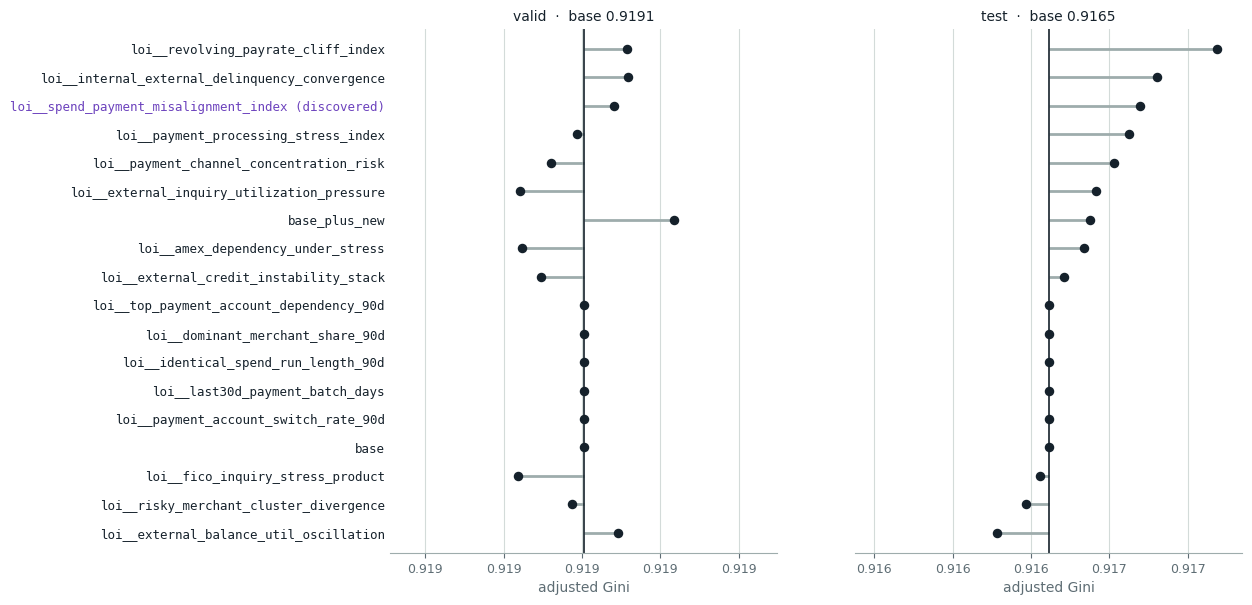

In [67]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Each variant's adjusted Gini on valid and on test, against base on the same split:
# a stem right of the line beats the incumbents there, a stem left of it loses.
splits = ["valid", "test"]
gini = (result.analysis.comparison.set_index("variant")
        [[f"adj_gini_{split}" for split in splits]]
        .set_axis(splits, axis=1)
        .sort_values("test"))                  # plotted bottom-up, so the best test Gini is on top
base = gini.loc["base"]
# One scale for both panels, centred on each split's base, so equal stems are equal changes.
span = (gini - base).abs().to_numpy().max() * 1.15

INK, MUTED, LINE, GRID, NEW = "#15212B", "#5E6D74", "#9EACAC", "#D3DBD9", "#6C42BD"

def label(variant):
    feature = variant.removeprefix("loi__")
    if feature.startswith("cand_"):
        return f"{variant} (planted)", MUTED
    if feature in discovered.kept_features:
        return f"{variant} (discovered)", NEW
    return variant, INK

rows = range(len(gini))
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(11, 0.3 * len(gini) + 1.4))
for ax, split in zip(axes, splits):
    ax.hlines(rows, base[split], gini[split], color=LINE, lw=2, zorder=1)
    ax.scatter(gini[split], rows, s=34, color=INK, zorder=3)
    ax.axvline(base[split], color=INK, lw=1.2, zorder=2)
    ax.set_title(f"{split}  ·  base {base[split]:.4f}", fontsize=10, color=INK)
    ax.set_xlim(base[split] - span, base[split] + span)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.3f}")
    ax.grid(axis="x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", colors=MUTED, labelsize=9)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(LINE)
    ax.set_xlabel("adjusted Gini", color=MUTED)

labels = [label(v) for v in gini.index]
axes[0].set_yticks(list(rows), [text for text, _ in labels], family="monospace", fontsize=9)
for tick, (_, color) in zip(axes[0].get_yticklabels(), labels):
    tick.set_color(color)
axes[0].set_ylim(-0.7, len(gini) - 0.3)
plt.show()

In [68]:
# Where the candidates land in the base_plus_new model's SHAP ranking.
ranking = result.analysis.feature_ranking.query("variant == 'base_plus_new'")
ranking[ranking["feature"].isin(result.dataset.new_features)][
    ["feature", "mean_abs_shap", "shap_share", "shap_rank"]].round(4)

,feature,mean_abs_shap,shap_share,shap_rank
322,external_inquiry_utilization_pressure,0.0823,0.0101,21
365,amex_dependency_under_stress,0.0390,0.0048,64
421,payment_processing_stress_index,0.0222,0.0027,120
435,payment_channel_concentration_risk,0.0176,0.0022,134
453,external_credit_instability_stack,0.0134,0.0017,152
460,risky_merchant_cluster_divergence,0.0126,0.0016,159
483,fico_inquiry_stress_product,0.0098,0.0012,182
490,spend_payment_misalignment_index,0.0087,0.0011,189
499,internal_external_delinquency_convergence,0.0074,0.0009,198
545,external_balance_util_oscillation,0.0019,0.0002,244


In [69]:
comparison = result.analysis.comparison.set_index("variant")
rows = []
for feature in result.dataset.new_features:
    variant = f"loi__{feature}"
    shap = result.analysis.shap_ranking.query("variant == @variant")
    if feature not in set(shap["feature"]):
        continue          # no base + one model for it
    row = shap.set_index("feature").loc[feature]
    rows.append({
        "feature": feature,
        "source": "discovered" if feature in discovered.kept_features else "declared",
        "shap_rank": int(row["shap_rank"]),
        "of": len(shap),
        "rank_pct": row["shap_rank"] / len(shap),
        "mean_abs_shap": row["mean_abs_shap"],
        "shap_share": row["shap_share"],
        "ratio": row["shap_share"] * len(shap),
        "gini_gain_test": comparison.loc[variant, "gini_gain_test"],
    })

pd.DataFrame(rows).sort_values("shap_rank").reset_index(drop=True).round(4)

,feature,source,shap_rank,of,rank_pct,mean_abs_shap,shap_share,ratio,gini_gain_test
0,external_inquiry_utilization_pressure,declared,17,303,0.0561,0.0896,0.0111,3.3780,0.0001
1,amex_dependency_under_stress,declared,64,303,0.2112,0.0375,0.0047,1.4145,0.0000
2,payment_channel_concentration_risk,declared,117,303,0.3861,0.0214,0.0027,0.8082,0.0001
3,payment_processing_stress_index,declared,133,303,0.4389,0.0180,0.0022,0.6797,0.0001
4,external_credit_instability_stack,declared,144,303,0.4752,0.0150,0.0019,0.5678,0.0000
5,fico_inquiry_stress_product,declared,159,303,0.5248,0.0126,0.0016,0.4729,-0.0000
6,risky_merchant_cluster_divergence,declared,165,303,0.5446,0.0117,0.0015,0.4416,-0.0000
7,internal_external_delinquency_convergence,declared,178,303,0.5875,0.0094,0.0012,0.3530,0.0001
8,spend_payment_misalignment_index,discovered,204,303,0.6733,0.0061,0.0008,0.2303,0.0001
9,external_balance_util_oscillation,declared,236,303,0.7789,0.0023,0.0003,0.0852,-0.0001


In [27]:
# Everything the run wrote; report.md is the human-readable summary.
for path in sorted(result.output_dir.rglob("*")):
    if path.is_file():
        print(path.relative_to(result.output_dir))

batch_verdict.json
candidate_verdicts.csv
config.resolved.yaml
data_quality_report.csv
feature_ranking.csv
feature_selection_decisions.json
feature_selection_mi_matrix.csv
feature_selection_redundancy.csv
feature_selection_spearman_matrix.csv
feature_selection_target_stats.csv
feature_selection_verdicts.csv
memory_by_stage.csv
metrics_by_variant_split.csv
models/base.json
models/base_plus_new.json
models/loi__amex_dependency_capacity_strain.json
models/loi__batch_payment_operational_risk_index.json
models/loi__concentrated_spend_ramp_pressure.json
models/loi__cross_system_delinquency_convergence.json
models/loi__exposure_capacity_mismatch.json
models/loi__external_credit_instability_index.json
models/loi__external_liquidity_pressure_index.json
models/loi__merchant_structuring_exposure_index.json
models/loi__paydown_collapse_index.json
models/loi__servicing_capacity_imbalance.json
models/loi__spend_payment_misalignment_stress.json
models/loi__supp_spend_dependency_index.json
report.md
r

<a id='4'></a>
## 4. The loop

One pass answers one question - did this batch earn a place? The loop keeps asking, and three things carry from one iteration to the next:

- **The incumbent set never changes.** Every proposal is judged the same way: base vs base plus that one feature (`leave_one_in`). A feature that clears every gate is **accepted as a candidate** - there are still steps before it can join a model - so each new batch is judged against the same base, not a moving one.
- **The history.** `discovery.history_path` records every proposal with its outcome and the reason: accepted, rejected at a gate and why, or rejected by the screen. Each run reads it into the prompt, so the proposer does not repeat an idea already judged, and appends its own proposals once the verdict is in.
- **The example rows keep rotating.** Round numbers continue across runs and round *r* shows few-shot batch *r*, cycling through all ten - so a new run never restarts at rows the proposer has already seen.

It stops after `MAX_ITERATIONS`, or after `PATIENCE` iterations in a row that accepted nothing.

In [24]:
MAX_ITERATIONS, PATIENCE = 3, 2

history_path = ROOT / "outputs" / "usage_loop_history.csv"
history_path.unlink(missing_ok=True)                            # a fresh study for this notebook
base_only = dataset.with_features(dataset.base_features, [])   # only what the proposer brings

accepted, misses = [], 0
for iteration in range(1, MAX_ITERATIONS + 1):
    cfg_loop = load_config(CONFIG, {"run.name": f"usage_loop_{iteration}", "run.log_level": "WARNING",
                                    "discovery.enabled": True,
                                    "discovery.history_path": str(history_path)})
    run = Pipeline(cfg_loop).run(dataset=base_only)
    passed = list(run.batch.passed)
    accepted += passed
    print(f"iteration {iteration}: {run.batch.verdict} - {len(passed)} of "
          f"{run.batch.n_candidates} accepted{': ' + ', '.join(passed) if passed else ''}")
    misses = 0 if passed else misses + 1
    if misses >= PATIENCE:
        print(f"stopping: {PATIENCE} iteration(s) in a row accepted nothing")
        break

print(f"\naccepted candidates, each judged base vs base + it: {accepted or 'none'}")

2026-09-15 22:50:46,582 | WARNING | discovery.stage              | model.params sets colsample_bytree < 1: base and leave_one_in variants differ in column count, so their gini gain includes an offset unrelated to any feature (a constant column measured -0.0055 on this data). The screen strips it for its own delta; set these to 1.0 to remove it from the verdict too.


2026-09-15 22:51:06,539 | WARNING | validation.pipeline          | no new features survived selection; only the baseline will be informative


iteration 1: TRY A NEW BATCH - 0 of 0 accepted
2026-09-15 22:51:13,711 | WARNING | discovery.stage              | model.params sets colsample_bytree < 1: base and leave_one_in variants differ in column count, so their gini gain includes an offset unrelated to any feature (a constant column measured -0.0055 on this data). The screen strips it for its own delta; set these to 1.0 to remove it from the verdict too.


2026-09-15 22:52:01,387 | WARNING | discovery.stage              | discovery: dropping 'revenue_diversity_index' - it passed the screen but fails on the full splits: Generated feature 'revenue_diversity_index' spikes on the train data: largest magnitude 1.16825e+10 is 585227074x its 99th percentile (19.9623), at row 1421. This is the signature of a division guarded with a tiny epsilon: adding 1e-6 to a zero denominator does not prevent a blow-up, it produces a value of order 1e6, which destroys the fit. Keep the result on a scale comparable to its inputs - mask the invalid rows, use a denominator that cannot approach zero, or clip the result.


iteration 2: TRY A NEW BATCH - 0 of 2 accepted
stopping: 2 iteration(s) in a row accepted nothing

accepted candidates, each judged base vs base + it: none


The history the loop built - every proposal, what became of it, and why:

In [25]:
history = pd.read_csv(history_path)
history[["run", "round", "feature_name", "outcome", "failed_at", "reason"]]

,run,round,feature_name,outcome,failed_at,reason
0,usage_loop_1/20260915_225046,1,asset_liability_contrast,rejected,screen,Generated feature 'asset_liability_contrast' is redundant: |rho|=0.983 again...
1,usage_loop_1/20260915_225046,1,persistent_to_quick_ratio,rejected,screen,Generated feature 'persistent_to_quick_ratio' is redundant: |rho|=0.961 agai...
2,usage_loop_1/20260915_225046,1,profitability_and_liquidity_interplay,rejected,screen,Generated feature 'profitability_and_liquidity_interplay' spikes on the samp...
3,usage_loop_1/20260915_225046,1,investment_efficiency_ratio,rejected,screen,Generated feature 'investment_efficiency_ratio' is redundant: |rho|=0.966 ag...
4,usage_loop_1/20260915_225046,1,growth_vs_turnover,rejected,screen,Generated feature 'growth_vs_turnover' is redundant: |rho|=0.996 against the...
5,usage_loop_1/20260915_225046,2,profit_leverage_interaction,rejected,screen,Generated feature 'profit_leverage_interaction' is redundant: |rho|=0.905 ag...
6,usage_loop_1/20260915_225046,2,liquidity_vs_operation,rejected,screen,Generated feature 'liquidity_vs_operation' spikes on the sample data: larges...
7,usage_loop_1/20260915_225046,2,earnings_to_debt_stability,rejected,screen,Generated feature 'earnings_to_debt_stability' is redundant: |rho|=0.990 aga...
8,usage_loop_1/20260915_225046,2,cash_flow_effectiveness,rejected,screen,Generated feature 'cash_flow_effectiveness' is redundant: |rho|=0.997 agains...
9,usage_loop_1/20260915_225046,2,equity_impact_factor,rejected,screen,Generated feature 'equity_impact_factor' is redundant: |rho|=0.924 against t...


And how the next iteration's proposer reads it - the same records, as they appear in its prompt:

In [26]:
from discovery.prompt import format_history

records = history.astype(object).where(history.notna(), None).to_dict("records")
print(format_history(records[-2:], "adjusted Gini"))

Previous code block 4:
```python
# (sustainability_equity_ratio, Equity sustainability measured by operating profits)
# Usefulness: Indicates how sustainable equity levels are against operating profit levels, offering insights into profit contributions to equity stability.
# Input samples: 'df["operating_profit_per_person"]': [0.397, 0.395, 0.393], 'df["current_liabilities_equity"]': [0.328, 0.331, 0.33]
df["sustainability_equity_ratio"] = df["operating_profit_per_person"] / df["current_liabilities_equity"].where(df["current_liabilities_equity"] != 0, np.nan)
```end
Score without the feature (adjusted Gini): 0.8567
Score with the feature (adjusted Gini): 0.8520
Change (adjusted Gini): -0.0047
Validated on the full data: REJECTED at the gini gain gate - gini gain +0.0107 on test (valid -0.0179), below +0.0050. Do not repeat this idea; propose something that avoids the reason it failed. It is not present in `df` for later blocks: every block starts from the same original columns.

Previo

Each iteration writes a full run directory under `outputs/usage_loop_<n>/`: `discovered_features.csv` is that iteration's proposals, and `report.md` its verdict. The accepted candidates are the loop's output - each passed base vs base + it on its own, and the steps that decide whether they enter a model come after.

**Before acting on an accepted candidate.** The thresholds live in the config (`verdict.min_gini_gain`, `verdict.require_valid_too`, `verdict.max_shap_rank_pct`), but they are blunt: with ~44 events in test a 0.005 gain sits inside the noise band, so repeat across seeds before trusting one. And nothing here detects leakage - a feature built from the outcome clears every gate and posts a large gain.

**Your own data.** Prepare the materials with `data/cdss_us_sbs/prepare.ipynb`, fill in its config, and point `CONFIG` at it.